<a href="https://colab.research.google.com/github/ruthAlt/Occupancy-Detection-ML/blob/main/notebooks/MLproject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
#import seaborn as sns
import random
import itertools

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import (train_test_split, learning_curve, validation_curve, KFold, StratifiedKFold, cross_val_score, GridSearchCV, RandomizedSearchCV, cross_validate, RepeatedStratifiedKFold)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import f1_score, roc_auc_score, confusion_matrix
from sklearn.linear_model import Perceptron, LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LinearDiscriminantAnalysis
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import FunctionTransformer, StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.feature_selection import SequentialFeatureSelector as SFS

from scipy.stats import loguniform, beta, uniform

from imblearn.over_sampling import SMOTE, RandomOverSampler
from imblearn.pipeline import Pipeline as IMBPipeline

import missingno as msno

import warnings
warnings.filterwarnings('ignore')

In [4]:
df = pd.read_csv('/content/drive/MyDrive/ML_Project/datatraining.txt')

In [8]:
df.head(5)

,date,Temperature,Humidity,Light,CO2,HumidityRatio,Occupancy
1,2015-02-04 17:51:00,23.18,27.2720,426.0,721.25,0.004793,1
2,2015-02-04 17:51:59,23.15,27.2675,429.5,714.00,0.004783,1
3,2015-02-04 17:53:00,23.15,27.2450,426.0,713.50,0.004779,1
4,2015-02-04 17:54:00,23.15,27.2000,426.0,708.25,0.004772,1
5,2015-02-04 17:55:00,23.10,27.2000,426.0,704.50,0.004757,1


In [9]:
target = 'Occupancy'
X = df.drop(columns=[target])
y = df[target]

In [10]:
X.head(10)

,date,Temperature,Humidity,Light,CO2,HumidityRatio
1,2015-02-04 17:51:00,23.180,27.2720,426.0,721.250000,0.004793
2,2015-02-04 17:51:59,23.150,27.2675,429.5,714.000000,0.004783
3,2015-02-04 17:53:00,23.150,27.2450,426.0,713.500000,0.004779
4,2015-02-04 17:54:00,23.150,27.2000,426.0,708.250000,0.004772
5,2015-02-04 17:55:00,23.100,27.2000,426.0,704.500000,0.004757
6,2015-02-04 17:55:59,23.100,27.2000,419.0,701.000000,0.004757
7,2015-02-04 17:57:00,23.100,27.2000,419.0,701.666667,0.004757
8,2015-02-04 17:57:59,23.100,27.2000,419.0,699.000000,0.004757
9,2015-02-04 17:58:59,23.100,27.2000,419.0,689.333333,0.004757
10,2015-02-04 18:00:00,23.075,27.1750,419.0,688.000000,0.004745


In [11]:
X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8143 entries, 1 to 8143
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           8143 non-null   object 
 1   Temperature    8143 non-null   float64
 2   Humidity       8143 non-null   float64
 3   Light          8143 non-null   float64
 4   CO2            8143 non-null   float64
 5   HumidityRatio  8143 non-null   float64
dtypes: float64(5), object(1)
memory usage: 703.4+ KB


In [13]:
def add_missing(col, amount):
  X = col.copy()
  size = amount if amount >= 1 else int(len(X)* amount)
  indexes = np.random.choice(len(X), size, replace=False)
  X.iloc[indexes] = np.nan
  return X

def add_missing_rows(df, amount):
  X = df.copy()
  rows, cols = X.shape
  size = amount if amount >= 1 else int(rows * amount)
  indexes = np.random.choice(rows, size, replace = False) + 0.5
  for i in indexes:
    X.loc[i] = np.full((cols,), np.nan)
  X = X.sort_index().reset_index(drop=True)
  return X

In [15]:
X['Light'] = add_missing(X['Light'], 0.10)
X['CO2'] = add_missing(X['CO2'], 0.05)
X['Temperature'] = add_missing(X['Temperature'], 100)

X = add_missing_rows(X, 0.01)

In [17]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8224 entries, 0 to 8223
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           8143 non-null   object 
 1   Temperature    8043 non-null   float64
 2   Humidity       8143 non-null   float64
 3   Light          7329 non-null   float64
 4   CO2            7736 non-null   float64
 5   HumidityRatio  8143 non-null   float64
dtypes: float64(5), object(1)
memory usage: 385.6+ KB


In [19]:
X.isnull().sum(axis=0) / X.shape[0]


,0
date,0.009849
Temperature,0.022009
Humidity,0.009849
Light,0.108828
CO2,0.059339
HumidityRatio,0.009849


<Axes: >

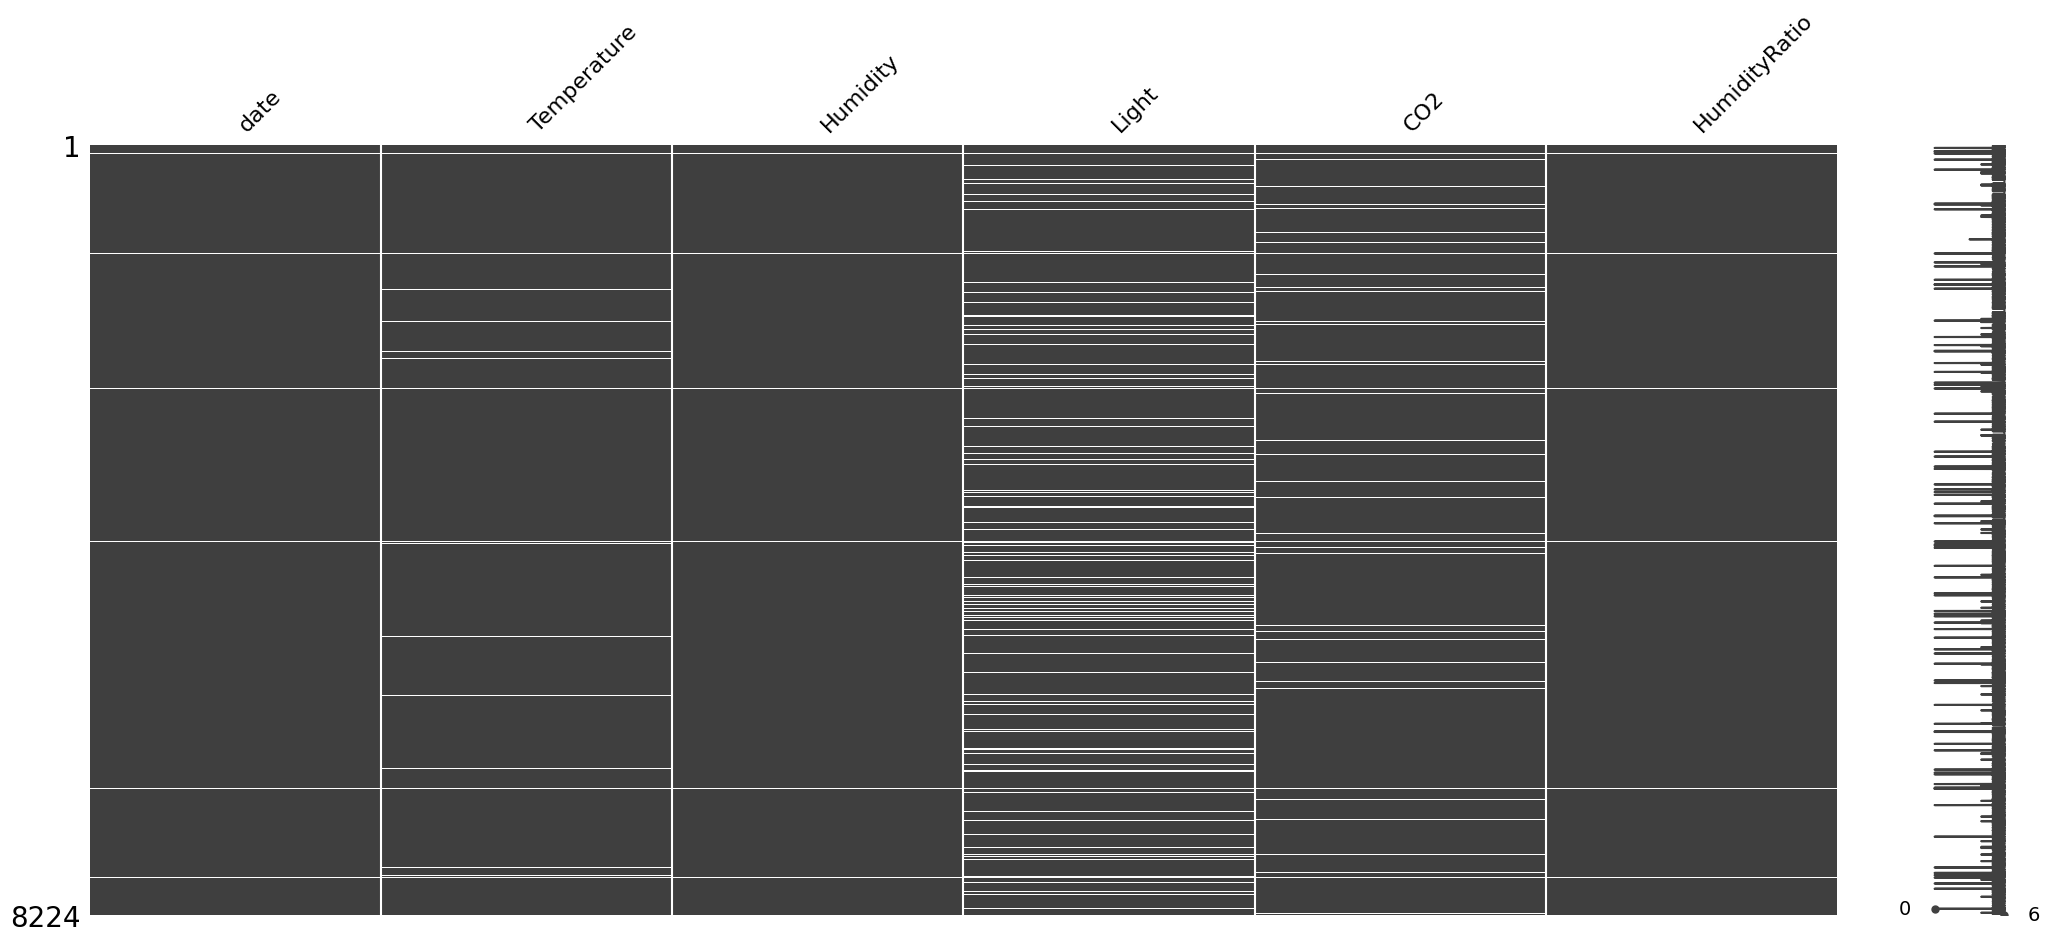

In [20]:
msno.matrix(X)

Since the missing vals are very little we will use imputation method to fill the gaps

# Data Transformation Pipeline